In [30]:
import matplotlib.pyplot as plt
import numpy as np
from timeit import default_timer as timer

import gropt as gropt

In [31]:
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')

### Test a simple M2=comped waveform and predict PNS with both SAFE models


Converged: False   Solve time: 201.0 ms


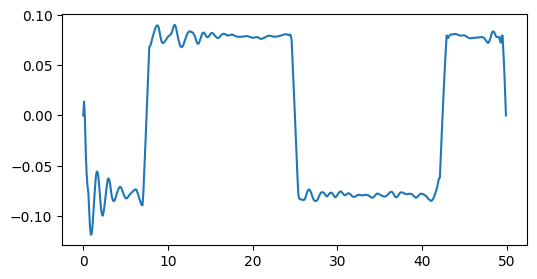

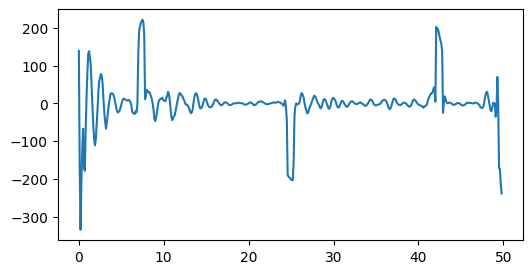

Max SAFE 1.240
Max SAFE Cardiac 1.094


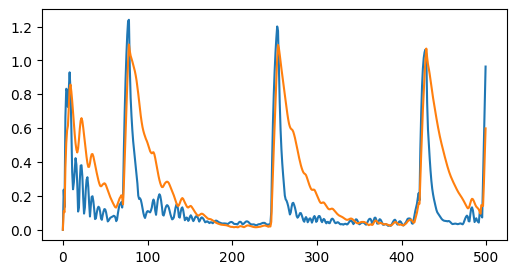

In [ ]:
gparams = gropt.GroptParams()
gparams.diff_init(dt=100e-6)
gparams.N = 500

gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)
gparams.add_bvalue(780,1)
gparams.add_TV(1e-3)

start_t = timer()
# gparams.init()
# gparams.solve()
# out = gparams.get_out()
result = gropt.solve(gparams, min_iter=100000)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')


# Plotting
# ------------------------
plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()

new_first_axis = 0
safe = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)
print(f'Max SAFE {np.max(safe):.3f}')
print(f'Max SAFE Cardiac {np.max(safe_cardiac):.3f}')
plt.figure(figsize=(6,3))
plt.plot(safe)
plt.plot(safe_cardiac)
plt.show()

### Now constrain the same parameters on BOTH safe models


Converged: False   Solve time: 892.5 ms


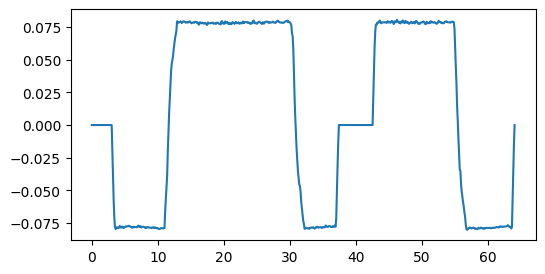

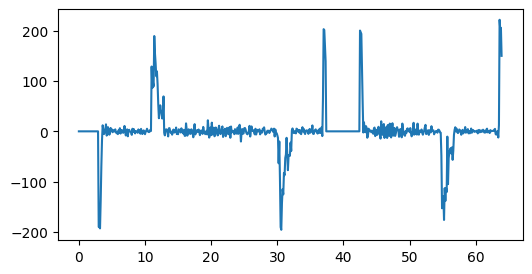

Max SAFE 0.871
Max SAFE Cardiac 0.808


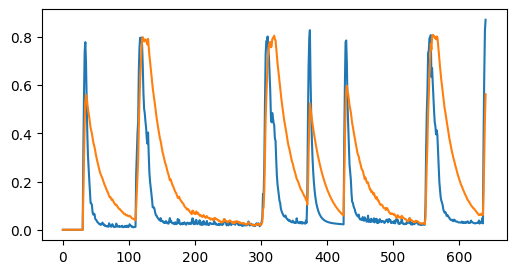

In [33]:
gparams = gropt.GroptParams()
gparams.diff_init(dt=100e-6)

# --- Set up constraints
gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)
gparams.add_bvalue(778,1)
gparams.add_SAFE(0.8, safe_params=safe_params)
gparams.add_SAFE(0.8, safe_params=safe_params_cardiac)

start_t = timer()
# gparams.init()
# gparams.solve(n_iter = 5000)
# out = gparams.get_out()
# stop_t = timer()

# print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms')

result = gropt.solve(gparams)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')

# Plotting
# ------------------------
plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()

new_first_axis = 0
safe = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)

print(f'Max SAFE {np.max(safe):.3f}')
print(f'Max SAFE Cardiac {np.max(safe_cardiac):.3f}')
plt.figure(figsize=(6,3))
plt.plot(safe)
plt.plot(safe_cardiac)
plt.show()

### The next two cells are testing pregularization methods to make waveforms look a little cleaner

Converged: True   Solve time: 194.7 ms


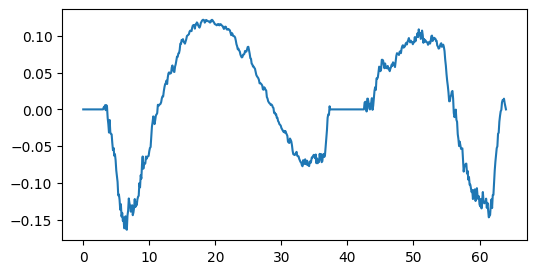

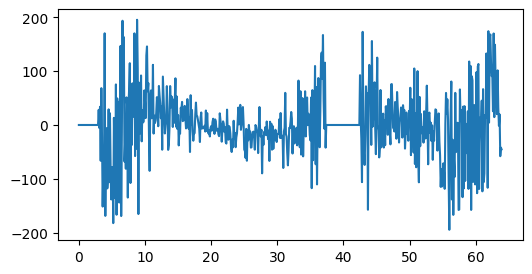

Max SAFE 0.773
Max SAFE Cardiac 0.929


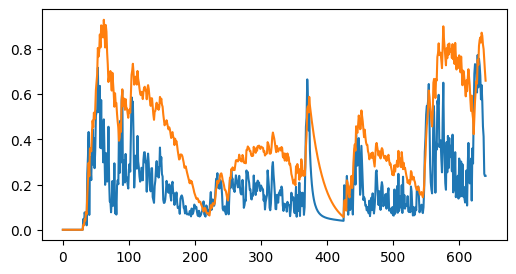

In [34]:
gparams = gropt.GroptParams()
gparams.diff_init(dt=100e-6)

# --- Set up constraints
gparams.add_gmax(.2)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)
gparams.add_bvalue(778,1)
gparams.add_SAFE(safe_params=safe_params)
gparams.add_SAFE(safe_params=safe_params_cardiac)

start_t = timer()
# gparams.init()
# gparams.solve(n_iter = 5000, ils_tik_lam=10)
# out = gparams.get_out()
# stop_t = timer()

# print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms')
result = gropt.solve(gparams)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')


# Plotting
# ------------------------
plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()

new_first_axis = 0
safe = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)

print(f'Max SAFE {np.max(safe):.3f}')
print(f'Max SAFE Cardiac {np.max(safe_cardiac):.3f}')

plt.figure(figsize=(6,3))
plt.plot(safe)
plt.plot(safe_cardiac)
plt.show()

Converged: False   Solve time: 911.4 ms


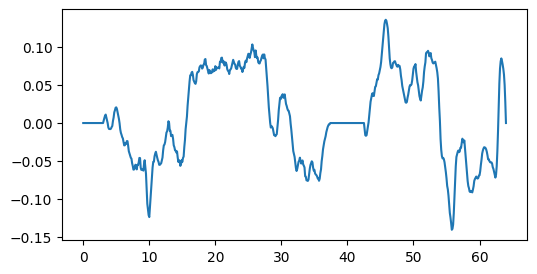

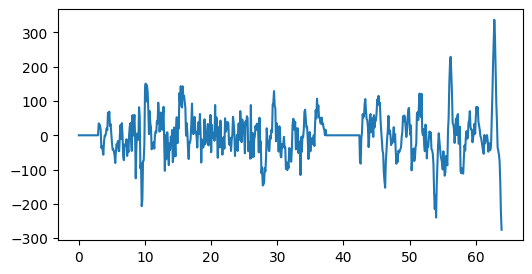

Max SAFE 1.397
Max SAFE Cardiac 1.095


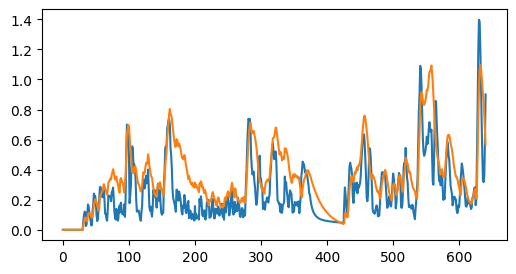

In [35]:
gparams = gropt.GroptParams()
gparams.diff_init(dt=100e-6)

# --- Set up constraints
gparams.add_gmax(.08)
gparams.add_smax(200)
gparams.add_moment(0,0.0)
gparams.add_moment(1,0.0)
gparams.add_moment(2,0.0)
gparams.add_bvalue(778,1)
gparams.add_SAFE(safe_params=safe_params)
gparams.add_SAFE(safe_params=safe_params_cardiac)
gparams.add_TV(10, 1)

start_t = timer()
# gparams.init()
# gparams.solve(n_iter = 5000)
# out = gparams.get_out()
# stop_t = timer()

# print(f'Final Good: {gparams.final_good>0}   Solve time: {1000*(stop_t-start_t):.1f} ms')
result = gropt.solve(gparams)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')


# Plotting
# ------------------------
plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size)*gparams.dt*1e3
plt.plot(tt_ms, out)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(tt_ms[:-1], np.diff(out)/gparams.dt)
plt.show()

new_first_axis = 0
safe = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac = gropt.gropt_wrapper.get_SAFE(out, gparams.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)

print(f'Max SAFE {np.max(safe):.3f}')
print(f'Max SAFE Cardiac {np.max(safe_cardiac):.3f}')

plt.figure(figsize=(6,3))
plt.plot(safe)
plt.plot(safe_cardiac)
plt.show()